--- 1. Підготовка та Аналіз Даних ---
Дані завантажено успішно.
Розмір тренувального набору: 22286
Розмір валідаційного набору: 7429
Розмір тестового набору: 7429


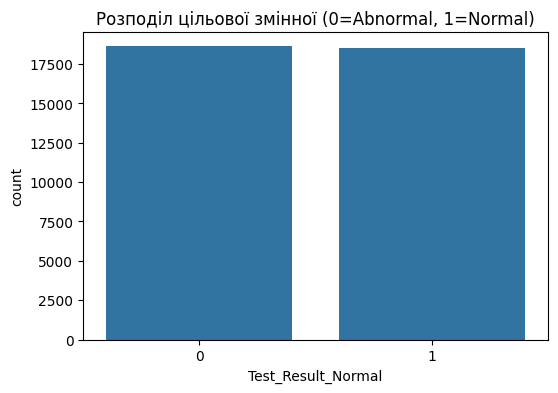

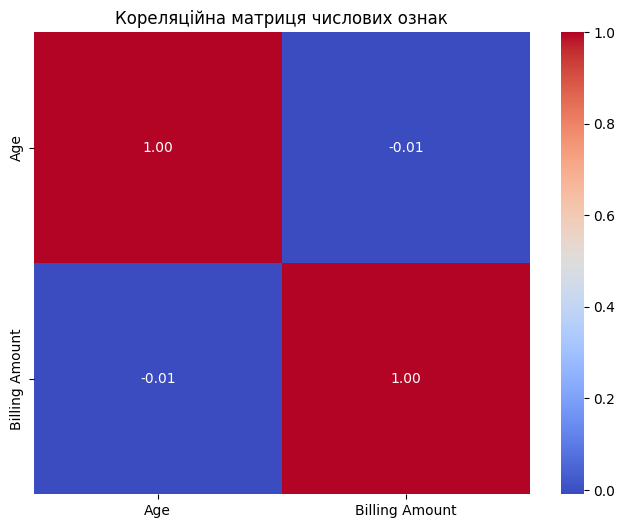

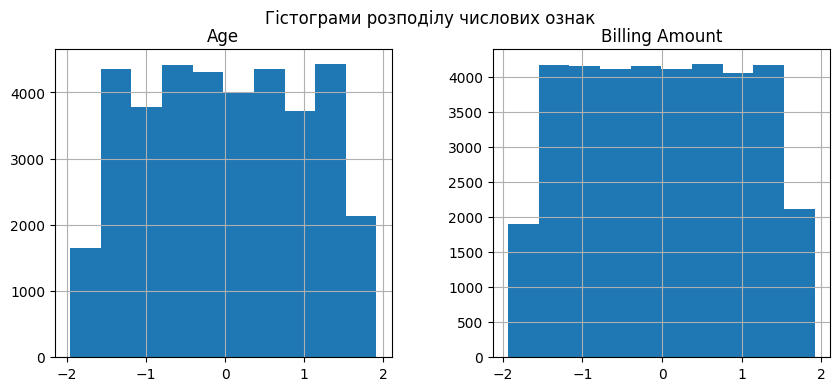


--- 2. Реалізація Логістичної Регресії ---

Навчання з mini-batch (LR=0.01, Lambda=0)
Епоха 10/200, Train Loss: 0.6927, Val Loss: 0.6937
Рання зупинка на епосі 11. Найкращий val loss: 0.6932


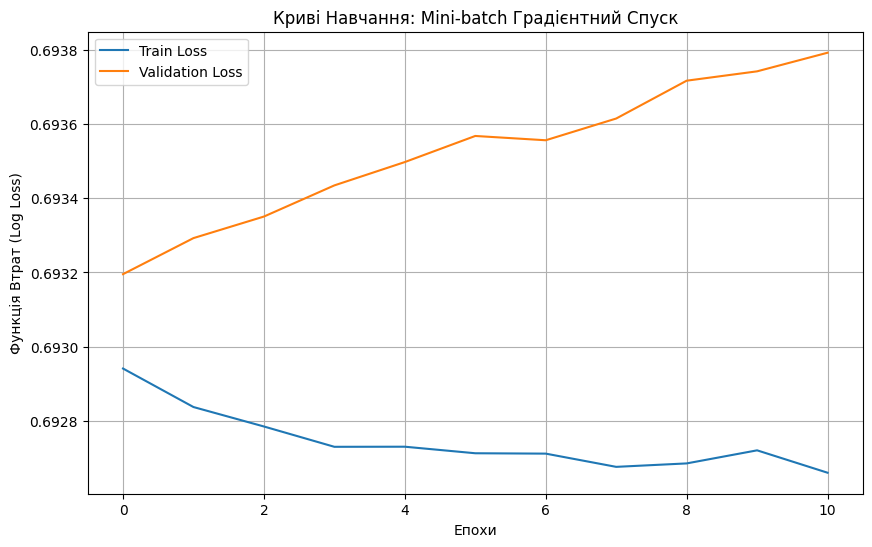


Навчання з sgd (LR=0.001, Lambda=0)
Епоха 10/200, Train Loss: 0.6927, Val Loss: 0.6942
Рання зупинка на епосі 11. Найкращий val loss: 0.6934


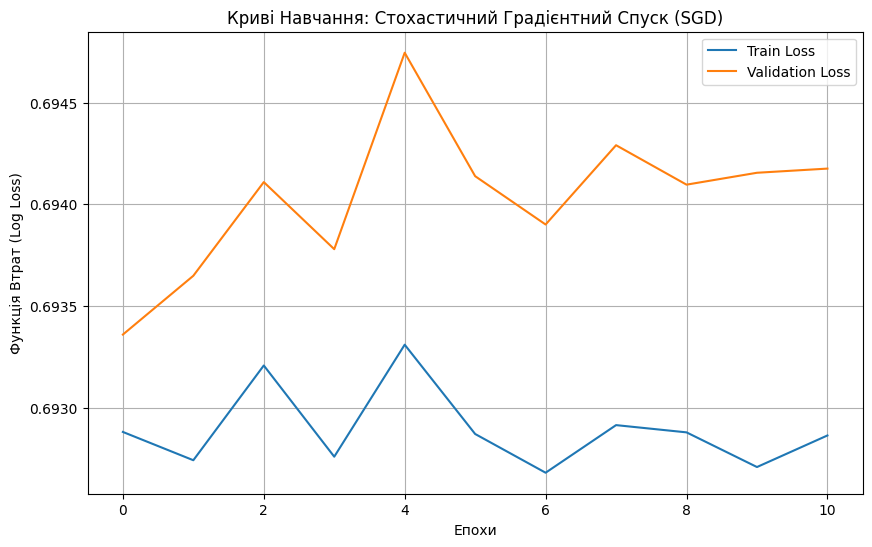


Навчання з mini-batch (LR=0.01, Lambda=0.1)
Епоха 10/200, Train Loss: 0.6927, Val Loss: 0.6936
Рання зупинка на епосі 11. Найкращий val loss: 0.6932

--- 4. Оцінка на Тестовому Наборі та Порівняння ---

Порівняльна Таблиця Метрик на Тестовому Наборі:
                 Accuracy  Precision    Recall  F1-score
Mini-batch GD    0.503702   0.502717  0.399676  0.445314
SGD              0.501413   0.499745  0.264920  0.346276
Mini-batch + L2  0.502759   0.503459  0.176884  0.261791


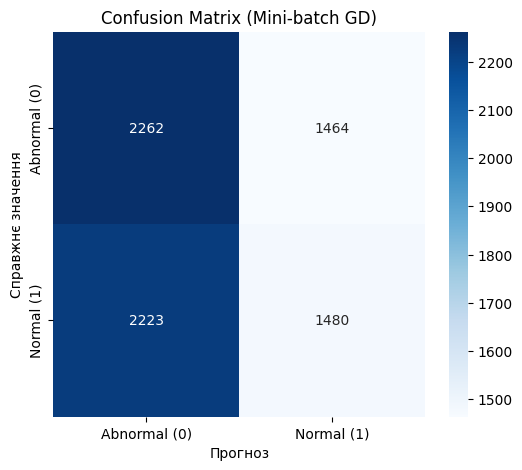

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------
# ЧАСТИНА 1: Підготовка та Аналіз Даних
# -----------------------------------------------------------------

print("--- 1. Підготовка та Аналіз Даних ---")

# Завантаження даних (ПРИПУЩЕННЯ: файл називається 'healthcare_dataset.csv')
# В оригінальному завданні вказано [Healthcare Dataset] Link, тому замініть назву
# файлу, якщо вона відрізняється.
try:
    df = pd.read_csv('healthcare_dataset.csv')
    print("Дані завантажено успішно.")
except FileNotFoundError:
    print("ПОМИЛКА: Файл 'healthcare_dataset.csv' не знайдено. Будь ласка, переконайтеся, що файл знаходиться у правильній директорії.")
    exit()

# [cite_start]Створення бінарної цільової змінної [cite: 26, 27]
df['Test_Result_Normal'] = (df['Test Results'] == 'Normal').astype(int)
# [cite_start]Видалення рядків з 'Inconclusive' (якщо обрано бінарну класифікацію) [cite: 10]
df = df[df['Test Results'] != 'Inconclusive'].copy()


# [cite_start]Видалення колонок, що не несуть прогностичної цінності [cite: 28]
cols_to_drop = ['Name', 'Date of Admission', 'Doctor', 'Hospital', 'Room Number', 'Discharge Date', 'Test Results', 'Patient ID']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


# [cite_start]One-Hot Encoding категоріальних ознак [cite: 29, 30]
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


# Визначення ознак (X) та цільової змінної (y)
X = df.drop('Test_Result_Normal', axis=1)
y = df['Test_Result_Normal']
numeric_cols = ['Age', 'Billing Amount']


# [cite_start]Нормалізація числових ознак [cite: 31]
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])


# [cite_start]Додавання Intercept (константи) - одиничного стовпця для вектора ознак [cite: 15, 53]
# Це спрощує матричні операції, оскільки intercept стає частиною вектора ваг $\theta$
X_with_intercept = np.hstack((np.ones((X.shape[0], 1)), X.values))


# [cite_start]Розподіл даних (60% тренувальний, 20% валідаційний, 20% тестовий) [cite: 37]
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_with_intercept, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val # 0.25 * 0.8 = 0.2 (20%)
)

# Перетворення y на numpy масиви
y_train = y_train.values.reshape(-1, 1)
y_val = y_val.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

print(f"Розмір тренувального набору: {X_train.shape[0]}")
print(f"Розмір валідаційного набору: {X_val.shape[0]}")
print(f"Розмір тестового набору: {X_test.shape[0]}")


# [cite_start]Аналіз даних (для Jupyter Notebook - не виконується у консолі, але обов'язково для звіту) [cite: 32]
# [cite_start]→ Розподіл цільової змінної [cite: 33]
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Test_Result_Normal'])
plt.title('Розподіл цільової змінної (0=Abnormal, 1=Normal)')
plt.show() # 
# [cite_start]→ Кореляційна матриця числових ознак [cite: 34, 126]
plt.figure(figsize=(8, 6))
sns.heatmap(X[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Кореляційна матриця числових ознак')
plt.show() # 
# [cite_start]→ Гістограми для візуалізації розподілів [cite: 35]
X[numeric_cols].hist(figsize=(10, 4))
plt.suptitle('Гістограми розподілу числових ознак')
plt.show() # 

# -----------------------------------------------------------------
# ЧАСТИНА 2: Реалізація Логістичної Регресії
# -----------------------------------------------------------------

print("\n--- 2. Реалізація Логістичної Регресії ---")

class LogisticRegressionFromScratch:
    def __init__(self, n_features):
        self.weights = np.zeros((n_features, 1))

    def sigmoid(self, z):
        z = np.asarray(z, dtype=np.float64)
        return np.where(z >= 0, 
                        1 / (1 + np.exp(-z)), 
                        np.exp(z) / (1 + np.exp(z)))

    def predict_proba(self, X):
        z = X @ self.weights
        return self.sigmoid(z)
    
    # інші методи залишаються без змін


    # [cite_start]Функція втрат (Log Loss / Binary Cross-Entropy) [cite: 17, 42]
    def compute_loss(self, X, y, lambda_reg=0, reg_type=None):
        m = len(y)
        h_theta = self.predict_proba(X)
        
        # Функція втрат: $-\frac{1}{m}\sum_{i=1}^{m}[y_{i}log(p_{i})+(1-y_{i})log(1-p_{i})]$
        # Запобігання log(0)
        h_theta = np.clip(h_theta, 1e-15, 1 - 1e-15)
        
        log_loss = - (1/m) * np.sum(y * np.log(h_theta) + (1 - y) * np.log(1 - h_theta))
        
        # [cite_start]Додавання члена регуляризації (для L1 та L2) [cite: 115, 116]
        reg_term = 0
        
        # [cite_start]Важливо: параметр зсуву (self.weights[0]) не регуляризується [cite: 113]
        theta_j = self.weights[1:] # Ваги без intercept
        
        if reg_type == 'l2':
            # [cite_start]L2: $J(\theta)+\frac{\lambda}{2m}\sum_{j=1}^{n}\theta_{j}^{2}$ [cite: 115]
            reg_term = (lambda_reg / (2 * m)) * np.sum(theta_j**2)
        elif reg_type == 'l1':
            # [cite_start]L1: $J(\theta)+\frac{\lambda}{m}\sum_{j=1}^{n}|\theta_{j}|$ [cite: 116]
            reg_term = (lambda_reg / m) * np.sum(np.abs(theta_j))
            
        return log_loss + reg_term

    # Обчислення градієнта
    def compute_gradients(self, X, y, lambda_reg=0, reg_type=None):
        m = len(y)
        h_theta = self.predict_proba(X)
        
        # Основна частина градієнта: $\frac{1}{m} X^T (\sigma(X\theta) - y)$
        error = h_theta - y
        gradient = (1/m) * (X.T @ error)
        
        # [cite_start]Додавання члена градієнта регуляризації (для L1 та L2) [cite: 117]
        reg_gradient = np.zeros_like(self.weights)
        theta_j = self.weights[1:] # Ваги без intercept
        
        if reg_type == 'l2':
            # Градієнт L2: $\frac{\lambda}{m}\theta_{j}$
            reg_gradient[1:] = (lambda_reg / m) * theta_j
        elif reg_type == 'l1':
            # Градієнт L1: $\frac{\lambda}{m} \text{sgn}(\theta_{j})$
            reg_gradient[1:] = (lambda_reg / m) * np.sign(theta_j)
            
        return gradient + reg_gradient

    # Функція для отримання батчів для Mini-batch GD
    def get_batches(self, X, y, batch_size):
        m = len(y)
        # Перемішування індексів
        indices = np.arange(m)
        np.random.shuffle(indices)
        
        for i in range(0, m, batch_size):
            batch_indices = indices[i:i + batch_size]
            yield X[batch_indices], y[batch_indices]


# -----------------------------------------------------------------
# ЧАСТИНА 3: Навчання (SGD та Mini-batch GD) та Криві Навчання
# -----------------------------------------------------------------

def train_model(X_train, y_train, X_val, y_val, n_features, optimizer='mini-batch', 
                learning_rate=0.01, max_epochs=100, batch_size=32, lambda_reg=0, reg_type=None, patience=10):
    
    # Ініціалізація моделі
    model = LogisticRegressionFromScratch(n_features)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_weights = model.weights.copy()
    
    print(f"\nНавчання з {optimizer} (LR={learning_rate}, Lambda={lambda_reg})")
    
    for epoch in range(max_epochs):
        
        # [cite_start]Вибір оптимізатора [cite: 106, 107]
        if optimizer == 'sgd':
            # [cite_start]SGD: batch_size = 1 [cite: 20, 50]
            batches = model.get_batches(X_train, y_train, batch_size=1)
        elif optimizer == 'mini-batch':
            # [cite_start]Mini-batch GD [cite: 21, 51]
            batches = model.get_batches(X_train, y_train, batch_size=batch_size)
        else:
            raise ValueError("Непідтримуваний оптимізатор.")

        # Ітерація по батчах для оновлення ваг
        for X_batch, y_batch in batches:
            # [cite_start]Обчислення градієнтів (для SGD/mini-batch m=розмір батча) [cite: 114]
            # Хоча для регуляризації член $\frac{1}{m}$ має бути для розміру *всього* набору,
            # у практичних реалізаціях SGD/mini-batch часто використовують розмір батча.
            # Тут використовуємо функцію compute_gradients, де m=розмір батча
            gradients = model.compute_gradients(X_batch, y_batch, lambda_reg=lambda_reg, reg_type=reg_type)
            
            # [cite_start]Оновлення ваг [cite: 84]
            model.weights = model.weights - learning_rate * gradients

        # [cite_start]Розрахунок втрат після епохи (використовуємо весь набір для моніторингу) [cite: 57, 58, 86, 87]
        train_loss = model.compute_loss(X_train, y_train, lambda_reg=lambda_reg, reg_type=reg_type)
        val_loss = model.compute_loss(X_val, y_val, lambda_reg=lambda_reg, reg_type=reg_type)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # [cite_start]Визначення найкращої моделі та Рання зупинка [cite: 70, 91, 99]
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.weights.copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Рання зупинка на епосі {epoch+1}. Найкращий val loss: {best_val_loss:.4f}")
                break
        
        if (epoch + 1) % 10 == 0:
            print(f"Епоха {epoch+1}/{max_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # [cite_start]Відновлення найкращих ваг [cite: 102, 103]
    model.weights = best_weights
    
    return model, train_losses, val_losses


# [cite_start]Функція для побудови кривих навчання [cite: 61]
def plot_learning_curves(train_losses, val_losses, title):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'Криві Навчання: {title}')
    plt.xlabel('Епохи') # [cite: 62]
    plt.ylabel('Функція Втрат (Log Loss)') # [cite: 63]
    plt.legend() # [cite: 64]
    plt.grid(True)
    plt.show() # 
# [cite_start]Функція для оцінки моделі [cite: 118]
def evaluate_model(model, X, y_true):
    # [cite_start]Обчислення прогнозів [cite: 119]
    y_proba = model.predict_proba(X)
    y_pred = (y_proba >= 0.5).astype(int)

    # [cite_start]Метрики [cite: 121]
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # [cite_start]Confusion Matrix [cite: 120]
    cm = confusion_matrix(y_true, y_pred)
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1, 'Confusion Matrix': cm}


# Навчання та оцінка - Mini-batch GD
model_mb, losses_mb_train, losses_mb_val = train_model(
    X_train, y_train, X_val, y_val, X_train.shape[1], 
    optimizer='mini-batch', learning_rate=0.01, max_epochs=200, batch_size=32
)

# [cite_start]Побудова кривих навчання для Mini-batch GD [cite: 108]
plot_learning_curves(losses_mb_train, losses_mb_val, 'Mini-batch Градієнтний Спуск')


# Навчання та оцінка - SGD
model_sgd, losses_sgd_train, losses_sgd_val = train_model(
    X_train, y_train, X_val, y_val, X_train.shape[1], 
    optimizer='sgd', learning_rate=0.001, max_epochs=200, batch_size=1 # SGD - це batch_size=1
)

# [cite_start]Побудова кривих навчання для SGD [cite: 108]
plot_learning_curves(losses_sgd_train, losses_sgd_val, 'Стохастичний Градієнтний Спуск (SGD)')


# [cite_start]Навчання та оцінка - Mini-batch GD з L2 Регуляризацією [cite: 111]
model_l2, losses_l2_train, losses_l2_val = train_model(
    X_train, y_train, X_val, y_val, X_train.shape[1], 
    optimizer='mini-batch', learning_rate=0.01, max_epochs=200, batch_size=32, 
    lambda_reg=0.1, reg_type='l2'
)

# -----------------------------------------------------------------
# ЧАСТИНА 4: Оцінка на Тестовому Наборі та Порівняння
# -----------------------------------------------------------------

print("\n--- 4. Оцінка на Тестовому Наборі та Порівняння ---")

# Оцінка моделей на тестовому наборі
results_mb = evaluate_model(model_mb, X_test, y_test)
results_sgd = evaluate_model(model_sgd, X_test, y_test)
results_l2 = evaluate_model(model_l2, X_test, y_test)


# [cite_start]Порівняльна таблиця метрик [cite: 127]
metrics_df = pd.DataFrame({
    'Mini-batch GD': {k: v for k, v in results_mb.items() if k != 'Confusion Matrix'},
    'SGD': {k: v for k, v in results_sgd.items() if k != 'Confusion Matrix'},
    'Mini-batch + L2': {k: v for k, v in results_l2.items() if k != 'Confusion Matrix'}
}).T
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-score']]
print("\nПорівняльна Таблиця Метрик на Тестовому Наборі:")
print(metrics_df)


# [cite_start]Візуалізація Confusion Matrix для найкращої моделі (наприклад, Mini-batch GD) [cite: 120]
plt.figure(figsize=(6, 5))
sns.heatmap(results_mb['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Abnormal (0)', 'Normal (1)'], yticklabels=['Abnormal (0)', 'Normal (1)'])
plt.xlabel('Прогноз')
plt.ylabel('Справжнє значення')
plt.title('Confusion Matrix (Mini-batch GD)')
plt.show() # 
# -----------------------------------------------------------------
# ЧАСТИНА 5: Висновки
# -----------------------------------------------------------------

# [cite_start]Висновки (потрібно додати у markdown-комірку в Jupyter Notebook) [cite: 124, 128]
# * Порівняння SGD та Mini-batch GD: Обговоріть, який з них швидше сходився,
#   [cite_start]який був більш стабільним (крива SGD має бути більш "шумною")[cite: 109].
# * Аналіз Кривих Навчання: Поясніть, чи спостерігалося перенавчання (валидаційна
#   [cite_start]крива зростає) або недонавчання (обидві високі)[cite: 66, 67, 69].
# * Оцінка: Поясніть, які класи помилково класифікуються найчастіше,
#   [cite_start]дивлячись на Confusion Matrix (False Positives та False Negatives)[cite: 122].
# * Вплив Регуляризації: Порівняйте метрики моделі з L2 (модель_l2) та без неї
#   (модель_mb) і зробіть висновок про вплив регуляризації.